In [1]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

Post the following to the discussion board:

Attach your visualization.

Explain the method you used to create the visualization.

Share what library you used.

Describe the results you found and what they tell you about the dataset you chose.


In [2]:
df = pd.read_csv('data/allvisits.csv')

In [3]:
df.describe()

,County FIPS,Year,Week
count,0.0,26240.000000,26240.000000
mean,NaN,2022.565625,26.234375
std,NaN,1.763041,15.294431
min,NaN,2020.000000,1.000000
25%,NaN,2021.000000,13.000000
50%,NaN,2023.000000,26.000000
75%,NaN,2024.000000,39.250000
max,NaN,2026.000000,53.000000


In [4]:
"""
df[(df["Entity"] == "China") & (df["Year"] == 2017)]
# GDP of China in 2017 using query
df.query('Entity == "China" and Year == 2017')

"""

'\ndf[(df["Entity"] == "China") & (df["Year"] == 2017)]\n# GDP of China in 2017 using query\ndf.query(\'Entity == "China" and Year == 2017\')\n\n'

In [5]:
df.columns

Index(['Report Date', 'Week Ending Date', 'Health Region', 'Health District',
       'Facility Type', 'County FIPS', 'Year', 'Week',
       'Percent of ED Visits Covid', 'Percent of ED Visits Influenza',
       'Percent of ED Visits RSV', 'Percent of ED Visits Combined',
       'Diagnosed Covid Count', 'Diagnosed Influenza Count',
       'Diagnosed RSV Count', 'Combined Respiratory Viruses Count'],
      dtype='str')

In [6]:
# +

df= df[df["Health Region"] != "Out of State"]

In [7]:
years = df["Year"].unique()
years

array([2025, 2021, 2020, 2022, 2023, 2024, 2026])

In [8]:
districts = df["Health District"].unique()
districts


<ArrowStringArray>
[       'Central Region',                'Crater',               'Henrico',
              'Piedmont',             'Southside',          'Chesterfield',
          'Chickahominy',              'Richmond',            'Chesapeake',
        'Eastern Region',         'Eastern Shore',               'Hampton',
               'Norfolk',             'Peninsula',            'Portsmouth',
          'Three Rivers',        'Virginia Beach',     'Western Tidewater',
             'Arlington',               'Fairfax',               'Loudoun',
            'Alexandria',       'Northern Region',        'Prince William',
    'Central Shenandoah',          'Lord Fairfax',            'Blue Ridge',
          'Rappahannock',  'Rappahannock Rapidan',      'Northwest Region',
             'Alleghany',      'Central Virginia',    'Cumberland Plateau',
             'Lenowisco',          'Mount Rogers',             'New River',
 'Pittsylvania-Danville',      'Southwest Region',         'West Pied

In [9]:
region = df["Health Region"].unique()
region

<ArrowStringArray>
[  'Central Region',   'Eastern Region',  'Northern Region',
 'Northwest Region', 'Southwest Region']
Length: 5, dtype: str

In [10]:
df[(df["Health District"] == "Arlington") & (df["Year"] == 2026)]

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count
9819,Feb 17 2026 9:00AM,2026-01-17,Northern Region,Arlington,Emergency Department,NaN,2026,2,0.0,3.4,0.8,4.2,0,34,8,42
10242,Feb 17 2026 9:00AM,2026-01-31,Northern Region,Arlington,Urgent Care,NaN,2026,4,2.2,5.6,0.0,7.3,*,10,0,13
10531,Feb 17 2026 9:00AM,2026-01-17,Northern Region,Arlington,Urgent Care,NaN,2026,2,0.6,10.5,0.0,11.1,*,35,0,37
10543,Feb 17 2026 9:00AM,2026-02-14,Northern Region,Arlington,Urgent Care,NaN,2026,6,1.5,3.4,0.0,4.2,*,9,0,11
11181,Feb 17 2026 9:00AM,2026-01-24,Northern Region,Arlington,Emergency Department,NaN,2026,3,0.4,2.5,0.7,3.6,*,24,7,35
11185,Feb 17 2026 9:00AM,2026-01-31,Northern Region,Arlington,Emergency Department,NaN,2026,4,0.2,1.9,0.5,2.6,*,16,*,22
11371,Feb 17 2026 9:00AM,2026-02-07,Northern Region,Arlington,Urgent Care,NaN,2026,5,1.8,2.9,0.0,4.7,5,8,0,13
11443,Feb 17 2026 9:00AM,2026-02-07,Northern Region,Arlington,Emergency Department,NaN,2026,5,0.0,1.7,0.4,2.1,0,17,*,21
11710,Feb 17 2026 9:00AM,2026-02-14,Northern Region,Arlington,Emergency Department,NaN,2026,6,0.4,1.1,0.2,1.6,*,11,*,17
11922,Feb 17 2026 9:00AM,2026-01-24,Northern Region,Arlington,Urgent Care,NaN,2026,3,1.2,8.4,0.0,9.6,*,29,0,33


In [11]:
#df_inf_count = df_va[df_va["Diagnosed Influenza Count"].apply(lambda x: x.isnumeric())]
df["FlueCount"] = pd.to_numeric(df["Diagnosed Influenza Count"], errors='coerce')
# Or simply:
# df['your_numeric_column'] = df['your_numeric_column'].astype(float)


In [12]:
df = df.dropna(subset="FlueCount")

In [13]:
df[df["FlueCount"].isna()]

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count,FlueCount


In [14]:
df_2025 = df[df["Year"] == 2025]
 
len(df_2025)

3230

<Axes: xlabel='FlueCount', ylabel='Health Region'>

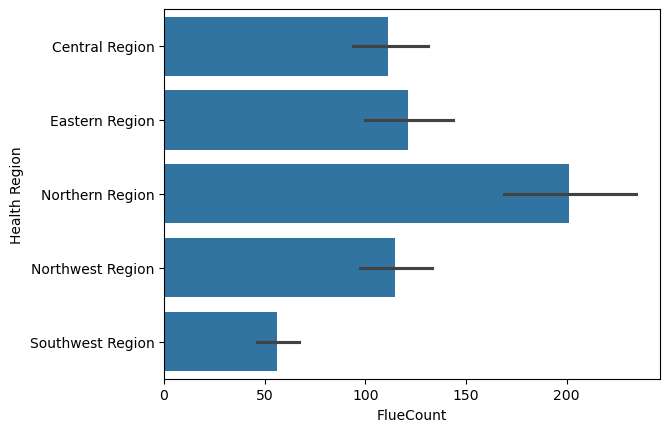

In [15]:
sns.barplot(data=df_2025, y="Health Region", x="FlueCount")

/tmp/ipykernel_60341/3475101695.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


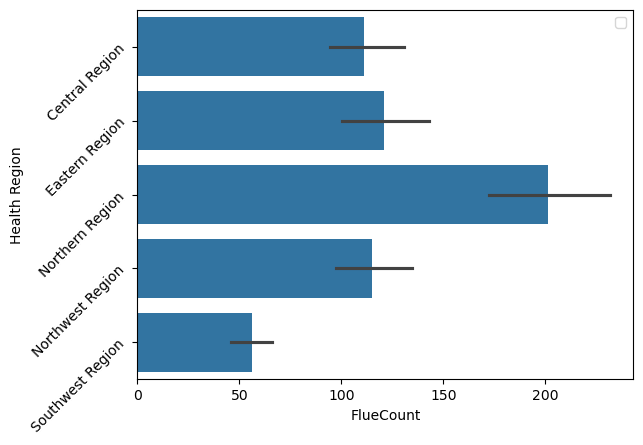

In [16]:


sns.barplot(data=df_2025, y="Health Region", x="FlueCount")
plt.yticks(rotation=45)
plt.legend();
#plt.savefig('images/flucount_2025.png')

In [17]:
fig = px.bar(df_2025, x="Health Region", y="FlueCount", color="Health Region")
#plt.savefig('images/flucount_2025.png', dpi=150)

In [18]:
df25Northern = df_2025[df_2025["Health Region"] == "Northern Region"]

In [19]:
n = df25Northern["Health District"].unique()
n

<ArrowStringArray>
[      'Arlington',         'Loudoun',         'Fairfax',      'Alexandria',
 'Northern Region',  'Prince William']
Length: 6, dtype: str

In [20]:
df25Northern = df25Northern[df25Northern["Health District"] != "Northern Region"]

In [21]:
df25Northern["Health District"].unique()

<ArrowStringArray>
['Arlington', 'Loudoun', 'Fairfax', 'Alexandria', 'Prince William']
Length: 5, dtype: str

In [22]:
fig = px.bar(df25Northern, x="Health District", y="FlueCount", color="Health District", height=600)
fig.write_image('images/flubar_2025.png')


In [23]:
df25Northern = df25Northern.dropna(subset="FlueCount")

In [24]:
len(df25Northern)

411

Text(0.5, 1.0, 'Northern Region')

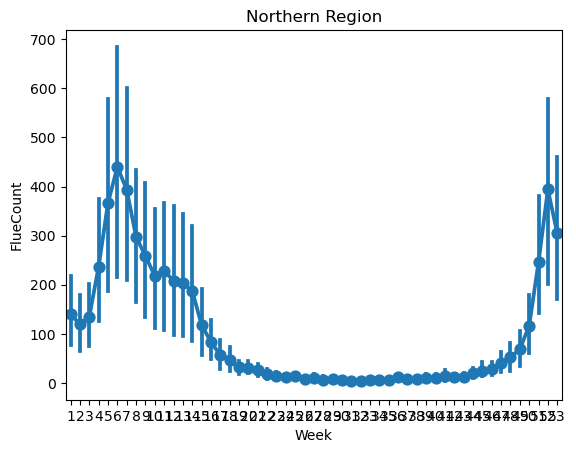

In [25]:
sns.pointplot(data=df25Northern, x="Week", y="FlueCount")
plt.title("Northern Region")
#plt.savefig('images/nova_scatter_2025.png', dpi=150, bbox_inches='tight')

In [26]:

dfEast = df_2025[df_2025["Health Region"] == "Eastern Region"]

In [27]:
dfEast

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count,FlueCount
2051,Feb 17 2026 9:00AM,2025-01-11,Eastern Region,Chesapeake,Emergency Department,NaN,2025,2,1.2,2.9,0.5,4.5,22,55,9,84,55.0
2053,Feb 17 2026 9:00AM,2025-01-18,Eastern Region,Chesapeake,Emergency Department,NaN,2025,3,0.7,6.3,0.3,7.3,16,137,6,158,137.0
2054,Feb 17 2026 9:00AM,2025-01-25,Eastern Region,Chesapeake,Emergency Department,NaN,2025,4,1.1,10.4,0.3,11.6,22,216,6,241,216.0
2062,Feb 17 2026 9:00AM,2025-03-08,Eastern Region,Chesapeake,Emergency Department,NaN,2025,10,1.1,2.2,0.1,3.4,22,45,*,69,45.0
2071,Feb 17 2026 9:00AM,2025-04-26,Eastern Region,Chesapeake,Emergency Department,NaN,2025,17,0.4,0.6,0.0,1.0,8,12,0,20,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25110,Feb 17 2026 9:00AM,2025-06-07,Eastern Region,Norfolk,Urgent Care,NaN,2025,23,0.7,1.0,0.0,1.7,10,14,0,24,14.0
25145,Feb 17 2026 9:00AM,2025-09-13,Eastern Region,Norfolk,Urgent Care,NaN,2025,37,2.6,0.7,0.0,3.2,39,11,0,48,11.0
25170,Feb 17 2026 9:00AM,2025-10-25,Eastern Region,Norfolk,Urgent Care,NaN,2025,43,0.7,0.8,0.0,1.4,10,12,0,21,12.0
25186,Feb 17 2026 9:00AM,2025-12-13,Eastern Region,Norfolk,Urgent Care,NaN,2025,50,0.8,4.2,0.1,5.0,12,62,*,74,62.0


In [28]:
dfEast = dfEast[dfEast["Health District"] != "Eastern Region"]

In [29]:
dfEast["Health District"].unique()

<ArrowStringArray>
[       'Chesapeake',           'Hampton',     'Eastern Shore',
           'Norfolk',         'Peninsula',        'Portsmouth',
      'Three Rivers',    'Virginia Beach', 'Western Tidewater']
Length: 9, dtype: str

In [30]:
dfEast = dfEast.dropna(subset="FlueCount")

In [31]:
dfEast

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count,FlueCount
2051,Feb 17 2026 9:00AM,2025-01-11,Eastern Region,Chesapeake,Emergency Department,NaN,2025,2,1.2,2.9,0.5,4.5,22,55,9,84,55.0
2053,Feb 17 2026 9:00AM,2025-01-18,Eastern Region,Chesapeake,Emergency Department,NaN,2025,3,0.7,6.3,0.3,7.3,16,137,6,158,137.0
2054,Feb 17 2026 9:00AM,2025-01-25,Eastern Region,Chesapeake,Emergency Department,NaN,2025,4,1.1,10.4,0.3,11.6,22,216,6,241,216.0
2062,Feb 17 2026 9:00AM,2025-03-08,Eastern Region,Chesapeake,Emergency Department,NaN,2025,10,1.1,2.2,0.1,3.4,22,45,*,69,45.0
2071,Feb 17 2026 9:00AM,2025-04-26,Eastern Region,Chesapeake,Emergency Department,NaN,2025,17,0.4,0.6,0.0,1.0,8,12,0,20,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25110,Feb 17 2026 9:00AM,2025-06-07,Eastern Region,Norfolk,Urgent Care,NaN,2025,23,0.7,1.0,0.0,1.7,10,14,0,24,14.0
25145,Feb 17 2026 9:00AM,2025-09-13,Eastern Region,Norfolk,Urgent Care,NaN,2025,37,2.6,0.7,0.0,3.2,39,11,0,48,11.0
25170,Feb 17 2026 9:00AM,2025-10-25,Eastern Region,Norfolk,Urgent Care,NaN,2025,43,0.7,0.8,0.0,1.4,10,12,0,21,12.0
25186,Feb 17 2026 9:00AM,2025-12-13,Eastern Region,Norfolk,Urgent Care,NaN,2025,50,0.8,4.2,0.1,5.0,12,62,*,74,62.0


Text(0.5, 1.0, 'Eastern Region')

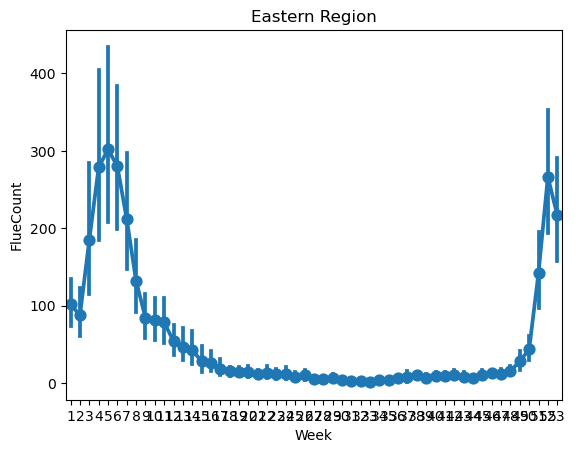

In [32]:
sns.pointplot(data=dfEast, x="Week", y="FlueCount")
plt.title("Eastern Region")
#plt.savefig('images/eastern_scatter_2025.png', dpi=150, bbox_inches='tight')